In [38]:
import numpy as np
import matplotlib.pyplot as plt

Gera a instância de 30 cidades

In [39]:
def gerar_instancia(n):
    return np.random.uniform(0, 100, size=(n, 2))

Gera a matriz das distâncias euclidianas

In [40]:
def matriz_dist(coordenada, n):
  dist_mat = np.zeros((n, n))
  for i in range(n):
    for j in range(n):
      dist_mat[i, j] = np.sqrt(np.sum((coordenada[i] - coordenada[j])**2))
  return dist_mat

Execução dos movimentos e armazena as pioras

In [41]:

def calibracao(n, dist_mat, tentativas):
  pioras = []

  tour = np.random.permutation(n)

  for _ in range(tentativas):

      i, j = sorted(np.random.choice(n, size=2, replace=False))

      if j == i + 1 or (i == 0 and j == n - 1):
          continue

      a, b = tour[i], tour[(i + 1) % n]
      c, d = tour[j], tour[(j + 1) % n]

      delta_f = (dist_mat[a, c] + dist_mat[b, d]) - (dist_mat[a, b] + dist_mat[c, d])

      if delta_f > 0:
          pioras.append(delta_f)

      tour[i+1 : j+1] = tour[i+1 : j+1][::-1]
  return pioras

Calculo da Temperatura Inicial

In [42]:
def calcular_temperatura_inicial(pioras, x0):
  delta_f_medio = np.mean(pioras)
  return -delta_f_medio / np.log(x0)

Calculo do Custo


In [43]:
def custo_total(tour, dist_matrix):
    custo = 0
    n = len(tour)
    for i in range(n):
        custo += dist_matrix[tour[i], tour[(i + 1) % n]]
    return custo

Simulated Annealing

In [44]:
def simulated_annealing(n_cidades, dist_mat, T0, alpha=0.95, T_min=0.1, max_iter=405, seed=None):
  if seed is not None:
    np.random.seed(seed)

  tour = np.random.permutation(n_cidades)
  melhor_tour = tour.copy()

  custo_atual = custo_total(tour, dist_mat)
  melhor_custo = custo_atual

  T = T0
  historico_melhor_custo = []

  while T > T_min:
    for it in range(1, max_iter):
      i, j = sorted(np.random.choice(n, size=2, replace=False))

      if j == i + 1 or (i == 0 and j == n - 1):
        continue

      a, b = tour[i], tour[(i + 1) % n]
      c, d = tour[j], tour[(j + 1) % n]

      delta_f = (dist_mat[a, c] + dist_mat[b, d]) - (dist_mat[a, b] + dist_mat[c, d])

      if ((delta_f < 0) or (np.random.uniform(0, 1) < np.exp(-delta_f/T))):
        tour[i+1 : j+1] = tour[i+1 : j+1][::-1]

        custo_atual += delta_f

        if custo_atual < melhor_custo:
          melhor_custo = custo_atual
          melhor_tour = tour.copy()

    historico_melhor_custo.append(melhor_custo)
    T *= alpha

  return melhor_custo, historico_melhor_custo, melhor_tour

Execução

Valor de T0 para X0(0.6): 62.76
Custo Médio Final para X0(0.6): 455.13
Desvio Padrão para X0(0.6): 4.55

Valor de T0 para X0(0.75): 111.43
Custo Médio Final para X0(0.75): 455.42
Desvio Padrão para X0(0.75): 7.08

Valor de T0 para X0(0.9): 304.26
Custo Médio Final para X0(0.9): 453.44
Desvio Padrão para X0(0.9): 2.66



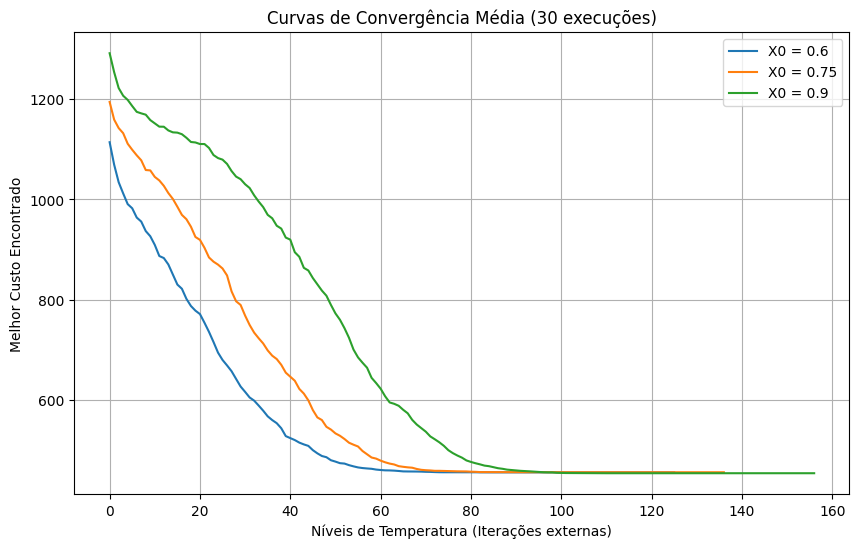

In [45]:
# Parametros
n = 30
x0 = [0.6, 0.75, 0.9]
execucoes = 30

np.random.seed(42) # Seed para definição das coordenadas das cidades

cords = gerar_instancia(n)
distancias = matriz_dist(cords, n)
pioras = calibracao(n, distancias, 1000)

resultados_por_x0 = {}

for _ in x0:
  t0 = calcular_temperatura_inicial(pioras, _)
  print(f"Valor de T0 para X0({_}): {t0:.2f}")

  custos_finais = []
  historico_custos = []
  melhor_tour_res = []

  for i in range(execucoes):
    melhor_c, hist, melhor_tour = simulated_annealing(n, distancias, T0=t0, seed=i)
    custos_finais.append(melhor_c)
    historico_custos.append(hist)

    melhor_tour_res.append(melhor_tour)

  resultados_por_x0[_] = {
        'custo_medio': np.mean(custos_finais),
        'desvio_padrao': np.std(custos_finais, ddof=1),
        'curva_media': np.mean(historico_custos, axis=0)
    }
  print(f"Custo Médio Final para X0({_}): {resultados_por_x0[_]['custo_medio']:.2f}")
  print(f"Desvio Padrão para X0({_}): {resultados_por_x0[_]['desvio_padrao']:.2f}\n")


plt.figure(figsize=(10, 6))
for i in x0:
    plt.plot(resultados_por_x0[i]['curva_media'], label=f'X0 = {i}')

plt.title("Curvas de Convergência Média (30 execuções)")
plt.xlabel("Níveis de Temperatura (Iterações externas)")
plt.ylabel("Melhor Custo Encontrado")
plt.legend()
plt.grid(True)
plt.show()